In [276]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import numpy as np 
import seaborn as sns
import folium
import plotly.express as px
import math


## Cleaning data 

Created two new dataframes. lfpl_df contains the inventory information for all libraries in Jefferson County, Kentucky. zip_df contains zip code for each branch as well as physical locations.  

In [277]:
lfpl_df = pd.read_csv("files/Louisville_Metro_KY_-_Library_Collection_Inventory.csv")
zip_df = pd.read_csv("files/Louisville_KY_Free_Public_Libraries (1).csv")

## Cleaning data
Item Location information (branch names) were inconsistent between the two files. Also, there was no 'zip code' on the inventory file. 


In [278]:
lfpl_df.head()

,BibNum,Title,Author,ISBN,PublicationYear,ItemType,ItemCollection,ItemLocation,ItemPrice,ReportDate,ObjectId
0,707409,"Jeff Immelt and the new GE way : innovation, t...","Magee, David, 1965-",9.780072e+12,2009,Book,Adult Non-Fiction,Main,25.95,2022/07/01 04:00:00+00,1
1,1341361,McGraw-Hill's American idioms dictionary,"Spears, Richard A.",9.780071e+12,2007,Book,ELL Collection,South Central,20.00,2022/07/01 04:00:00+00,2
2,707411,Robin rescues dinner : 52 weeks of quick-fix m...,"Miller, Robin, 1964-",9.780307e+12,2009,Book,Adult Non-Fiction,Southwest,19.99,2022/07/01 04:00:00+00,3
3,1341362,McGraw-Hill's essential ESL grammar : a handbo...,"Lester, Mark.",9.780071e+12,2008,Book,ELL Collection,South Central,20.00,2022/07/01 04:00:00+00,4
4,707411,Robin rescues dinner : 52 weeks of quick-fix m...,"Miller, Robin, 1964-",9.780307e+12,2009,Book,Adult Non-Fiction,Southwest,19.99,2022/07/01 04:00:00+00,5


In [279]:
lfpl_df['ItemLocation'].unique()

array(['Main', 'South Central', 'Southwest', 'Remote Shelving - Main',
       'Iroquois', 'Newburg', 'Shively', 'Bon Air', 'St Matthews',
       'Northeast', 'Fairdale', 'Middletown', 'Jeffersontown', 'Shawnee',
       'Highlands - Shelby Park', 'Crescent Hill', 'Portland', 'Western',
       'Remote Shelving - Shawnee', 'Childrens Main Library', 'Main Teen',
       'Childrens Bookmobile', 'Adult Bookmobile', 'Content Management'],
      dtype=object)

In [280]:
zip_df['LFPL_NAME'].unique()

array(['BON AIR', 'FAIRDALE', 'IROQUOIS', 'CRESCENT HILL',
       'JEFFERSONTOWN', 'HIGHLANDS-SHELBY PARK', 'MIDDLETOWN',
       'ST. MATTHEWS', 'SOUTH CENTRAL REGIONAL', 'PORTLAND', 'SHIVELY',
       'SHAWNEE', 'MAIN', 'NEWBURG', 'PARKLAND', 'NORTHEAST REGIONAL',
       'WESTERN', 'SOUTHWEST REGIONAL', 'FERN CREEK'], dtype=object)

# Data Cleaning 
Taking the unique names from each dataset I matched and replaced them in the inventory dataframe

In [281]:
lfpl_df['ItemLocation'] = lfpl_df['ItemLocation'].replace('Main','MAIN')
lfpl_df['ItemLocation'] = lfpl_df['ItemLocation'].replace('South Central','SOUTH CENTRAL REGIONAL')
lfpl_df['ItemLocation'] = lfpl_df['ItemLocation'].replace('Southwest','SOUTHWEST REGIONAL')
lfpl_df['ItemLocation'] = lfpl_df['ItemLocation'].replace('Iroquois','IROQUOIS')
lfpl_df['ItemLocation'] = lfpl_df['ItemLocation'].replace('Newburg','NEWBURG')
lfpl_df['ItemLocation'] = lfpl_df['ItemLocation'].replace('Shively','SHIVELY')
lfpl_df['ItemLocation'] = lfpl_df['ItemLocation'].replace('Bon Air','BON AIR')
lfpl_df['ItemLocation'] = lfpl_df['ItemLocation'].replace('St Matthews','ST. MATTHEWS')
lfpl_df['ItemLocation'] = lfpl_df['ItemLocation'].replace('Northeast','NORTHEAST REGIONAL')
lfpl_df['ItemLocation'] = lfpl_df['ItemLocation'].replace('Fairdale','FAIRDALE')
lfpl_df['ItemLocation'] = lfpl_df['ItemLocation'].replace('Middletown','MIDDLETOWN')
lfpl_df['ItemLocation'] = lfpl_df['ItemLocation'].replace('Jeffersontown','JEFFERSONTOWN')
lfpl_df['ItemLocation'] = lfpl_df['ItemLocation'].replace('Shawnee','SHAWNEE')
lfpl_df['ItemLocation'] = lfpl_df['ItemLocation'].replace('Highlands - Shelby Park','HIGHLANDS-SHELBY PARK')
lfpl_df['ItemLocation'] = lfpl_df['ItemLocation'].replace('Crescent Hill','CRESCENT HILL')
lfpl_df['ItemLocation'] = lfpl_df['ItemLocation'].replace('Portland','PORTLAND')
lfpl_df['ItemLocation'] = lfpl_df['ItemLocation'].replace('Western','WESTERN')
lfpl_df['ItemLocation'] = lfpl_df['ItemLocation'].replace('Remote Shelving - Shawnee','SHAWNEE')
lfpl_df['ItemLocation'] = lfpl_df['ItemLocation'].replace('Childrens Main Library','MAIN')
lfpl_df['ItemLocation'] = lfpl_df['ItemLocation'].replace('Main Teen','MAIN')
lfpl_df['ItemLocation'] = lfpl_df['ItemLocation'].replace('Content Management','MAIN')
lfpl_df['ItemLocation'] = lfpl_df['ItemLocation'].replace('Remote Shelving - Main','MAIN')


# Data cleaning
Verification that all names are now comparative between both DF's

In [282]:
lfpl_df['ItemLocation'].unique()

array(['MAIN', 'SOUTH CENTRAL REGIONAL', 'SOUTHWEST REGIONAL', 'IROQUOIS',
       'NEWBURG', 'SHIVELY', 'BON AIR', 'ST. MATTHEWS',
       'NORTHEAST REGIONAL', 'FAIRDALE', 'MIDDLETOWN', 'JEFFERSONTOWN',
       'SHAWNEE', 'HIGHLANDS-SHELBY PARK', 'CRESCENT HILL', 'PORTLAND',
       'WESTERN', 'Childrens Bookmobile', 'Adult Bookmobile'],
      dtype=object)

# Data Wrangling

Changed the name to lower in order to keep information consistent now that both DataFrames shared the same naming conventions. 

In [283]:
lfpl_df['Name_lower'] = lfpl_df['ItemLocation'].str.lower()
zip_df['Name_lower'] = zip_df['LFPL_NAME'].str.lower()

# Data Wrangling

I wanted a new Full Use CSV file. I wanted to match location information from the inventory dataframe (ZIP code) without changing my original CSV. 

In [284]:
merged = pd.merge(
    lfpl_df, zip_df[['Name_lower', 'ZIP']],
    on = 'Name_lower', how = 'left'
)

merged.drop(columns=['Name_lower'], inplace=True)
merged.to_csv('files/merged_2.csv', index = False)

# Data Wrangling

Created a dataframe using my new CSV file (correct naming conventions and zip information)
Also, created a dataframe to show my census data by zip code

In [285]:
merged_df = pd.read_csv("files/merged_2.csv")
census_df = pd.read_csv("files/Census_by_County.csv")

# Data Analysis 

Started the process of picking around that data to see if any questions came to mind or if any interesting trends became apparent. 

In [286]:
merged_df.head()

,BibNum,Title,Author,ISBN,PublicationYear,ItemType,ItemCollection,ItemLocation,ItemPrice,ReportDate,ObjectId,ZIP
0,707409,"Jeff Immelt and the new GE way : innovation, t...","Magee, David, 1965-",9.780072e+12,2009,Book,Adult Non-Fiction,MAIN,25.95,2022/07/01 04:00:00+00,1,40203.0
1,1341361,McGraw-Hill's American idioms dictionary,"Spears, Richard A.",9.780071e+12,2007,Book,ELL Collection,SOUTH CENTRAL REGIONAL,20.00,2022/07/01 04:00:00+00,2,40219.0
2,707411,Robin rescues dinner : 52 weeks of quick-fix m...,"Miller, Robin, 1964-",9.780307e+12,2009,Book,Adult Non-Fiction,SOUTHWEST REGIONAL,19.99,2022/07/01 04:00:00+00,3,40272.0
3,1341362,McGraw-Hill's essential ESL grammar : a handbo...,"Lester, Mark.",9.780071e+12,2008,Book,ELL Collection,SOUTH CENTRAL REGIONAL,20.00,2022/07/01 04:00:00+00,4,40219.0
4,707411,Robin rescues dinner : 52 weeks of quick-fix m...,"Miller, Robin, 1964-",9.780307e+12,2009,Book,Adult Non-Fiction,SOUTHWEST REGIONAL,19.99,2022/07/01 04:00:00+00,5,40272.0


In [287]:
census_df.head()

,ZIP Code,Town,State Abbreviation,State,Metro,Primary County,Total population,Median Household Income,Male,Female,...,Not Hispanic or Latino - White alone.1,Not Hispanic or Latino - Black or African American alone.1,Not Hispanic or Latino - American Indian and Alaska Native alone.1,Not Hispanic or Latino - Asian alone.1,Not Hispanic or Latino - Native Hawaiian and Other Pacific Islander alone.1,Not Hispanic or Latino - Some Other Race alone.1,Not Hispanic or Latino - Two or More Races.1,"Citizen, 18 and over population - Male.1","Citizen, 18 and over population - Female.1",Total housing units
0,40023,Fisherville,KY,Kentucky,"Louisville/Jefferson County, KY-IN",Jefferson County,"6,484","$135,863","3,395","3,089",...,84.1,7.1,0.0,3.1,0.0,0.3,0.9,49.2,50.8,"2,377"
1,40025,Glenview,KY,Kentucky,"Louisville/Jefferson County, KY-IN",Jefferson County,652,NaN,327,325,...,75.6,0.0,0.0,3.7,0.0,0.0,4.3,55.9,44.1,259
2,40041,Masonic Home,KY,Kentucky,"Louisville/Jefferson County, KY-IN",Jefferson County,518,NaN,153,365,...,91.3,6.9,1.5,0.0,0.0,0.0,0.2,29.5,70.5,291
3,40059,Prospect,KY,Kentucky,"Louisville/Jefferson County, KY-IN",Jefferson County,"19,899","$165,000","9,878","10,021",...,86.4,4.0,0.0,4.3,0.0,0.1,2.8,48.8,51.2,"8,400"
4,40118,Fairdale,KY,Kentucky,"Louisville/Jefferson County, KY-IN",Jefferson County,"9,903","$52,257","5,214","4,689",...,76.3,2.0,0.0,0.0,0.0,0.0,2.2,50.4,49.6,"4,405"


# Data Analysis

Looked into the amount titles in the library that had the most copies to see which books were the most widely held. 

Courier-Journal, The Blood-horse, People weekly, Annual Reports and Consumer Reports are all newspapers and magazines. 

In [288]:
title_counts = merged_df['Title'].value_counts().reset_index()
title_counts.columns = ['Title', 'title_count']
title_counts

,Title,title_count
0,The courier-journal,1352
1,The Blood-horse.,1028
2,People weekly.,909
3,Annual report.,588
4,Consumer reports.,498
...,...,...
601960,Jeeves and the wedding bells : an homage to P....,1
601961,Sandrine's Case,1
601962,Ghostgirl : lovesick,1
601963,Daughters of the sea : Hannah,1


# Data Analysis

Wanted to pull census data into the dataframe but was unable to because my zip and zipcode dtypes information varied between the two data frames. Changed both to Integers

In [289]:
merged_df["ZIP"] = pd.to_numeric(merged_df["ZIP"], errors="coerce").astype("Int64")
census_df["ZIP Code"] = pd.to_numeric(census_df["ZIP Code"], errors="coerce").astype("Int64")

# Data Cleanup and Wrangling

Now that both were integers I was able to connect the total population line to my dataframe based on Zip Code. Dropped Zip Code from my dataframe as it was a duplicate. 

In [290]:
merged_df = merged_df.merge(
    census_df[['ZIP Code', 'Total population']],
    how = 'left',
    left_on='ZIP',
    right_on='ZIP Code'
)

merged_df.drop(columns='ZIP Code', inplace=True)

In [291]:
merged_df['ZIP'] = pd.to_numeric(merged_df['ZIP'], errors='coerce').fillna(0).astype(int)
merged_df

,BibNum,Title,Author,ISBN,PublicationYear,ItemType,ItemCollection,ItemLocation,ItemPrice,ReportDate,ObjectId,ZIP,Total population
0,707409,"Jeff Immelt and the new GE way : innovation, t...","Magee, David, 1965-",9.780072e+12,2009,Book,Adult Non-Fiction,MAIN,25.95,2022/07/01 04:00:00+00,1,40203,"17,540"
1,1341361,McGraw-Hill's American idioms dictionary,"Spears, Richard A.",9.780071e+12,2007,Book,ELL Collection,SOUTH CENTRAL REGIONAL,20.00,2022/07/01 04:00:00+00,2,40219,"39,107"
2,707411,Robin rescues dinner : 52 weeks of quick-fix m...,"Miller, Robin, 1964-",9.780307e+12,2009,Book,Adult Non-Fiction,SOUTHWEST REGIONAL,19.99,2022/07/01 04:00:00+00,3,40272,"37,595"
3,1341362,McGraw-Hill's essential ESL grammar : a handbo...,"Lester, Mark.",9.780071e+12,2008,Book,ELL Collection,SOUTH CENTRAL REGIONAL,20.00,2022/07/01 04:00:00+00,4,40219,"39,107"
4,707411,Robin rescues dinner : 52 weeks of quick-fix m...,"Miller, Robin, 1964-",9.780307e+12,2009,Book,Adult Non-Fiction,SOUTHWEST REGIONAL,19.99,2022/07/01 04:00:00+00,5,40272,"37,595"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1657550,2527332,The afrominimalist's guide to living with less,"Platt, Christine",9.781982e+12,2022,Book,Adult Non-Fiction,MAIN,10.02,2022/07/01 04:00:00+00,1657551,40203,"17,540"
1657551,2527332,The afrominimalist's guide to living with less,"Platt, Christine",9.781982e+12,2022,Book,Adult Non-Fiction,NEWBURG,10.02,2022/07/01 04:00:00+00,1657552,40218,"33,292"
1657552,2527332,The afrominimalist's guide to living with less,"Platt, Christine",9.781982e+12,2022,Book,Adult Non-Fiction,SOUTH CENTRAL REGIONAL,10.02,2022/07/01 04:00:00+00,1657553,40219,"39,107"
1657553,2527332,The afrominimalist's guide to living with less,"Platt, Christine",9.781982e+12,2022,Book,Adult Non-Fiction,WESTERN,10.02,2022/07/01 04:00:00+00,1657554,40203,"17,540"


In [292]:
merged_df

,BibNum,Title,Author,ISBN,PublicationYear,ItemType,ItemCollection,ItemLocation,ItemPrice,ReportDate,ObjectId,ZIP,Total population
0,707409,"Jeff Immelt and the new GE way : innovation, t...","Magee, David, 1965-",9.780072e+12,2009,Book,Adult Non-Fiction,MAIN,25.95,2022/07/01 04:00:00+00,1,40203,"17,540"
1,1341361,McGraw-Hill's American idioms dictionary,"Spears, Richard A.",9.780071e+12,2007,Book,ELL Collection,SOUTH CENTRAL REGIONAL,20.00,2022/07/01 04:00:00+00,2,40219,"39,107"
2,707411,Robin rescues dinner : 52 weeks of quick-fix m...,"Miller, Robin, 1964-",9.780307e+12,2009,Book,Adult Non-Fiction,SOUTHWEST REGIONAL,19.99,2022/07/01 04:00:00+00,3,40272,"37,595"
3,1341362,McGraw-Hill's essential ESL grammar : a handbo...,"Lester, Mark.",9.780071e+12,2008,Book,ELL Collection,SOUTH CENTRAL REGIONAL,20.00,2022/07/01 04:00:00+00,4,40219,"39,107"
4,707411,Robin rescues dinner : 52 weeks of quick-fix m...,"Miller, Robin, 1964-",9.780307e+12,2009,Book,Adult Non-Fiction,SOUTHWEST REGIONAL,19.99,2022/07/01 04:00:00+00,5,40272,"37,595"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1657550,2527332,The afrominimalist's guide to living with less,"Platt, Christine",9.781982e+12,2022,Book,Adult Non-Fiction,MAIN,10.02,2022/07/01 04:00:00+00,1657551,40203,"17,540"
1657551,2527332,The afrominimalist's guide to living with less,"Platt, Christine",9.781982e+12,2022,Book,Adult Non-Fiction,NEWBURG,10.02,2022/07/01 04:00:00+00,1657552,40218,"33,292"
1657552,2527332,The afrominimalist's guide to living with less,"Platt, Christine",9.781982e+12,2022,Book,Adult Non-Fiction,SOUTH CENTRAL REGIONAL,10.02,2022/07/01 04:00:00+00,1657553,40219,"39,107"
1657553,2527332,The afrominimalist's guide to living with less,"Platt, Christine",9.781982e+12,2022,Book,Adult Non-Fiction,WESTERN,10.02,2022/07/01 04:00:00+00,1657554,40203,"17,540"


In [293]:
merged_df.head()

,BibNum,Title,Author,ISBN,PublicationYear,ItemType,ItemCollection,ItemLocation,ItemPrice,ReportDate,ObjectId,ZIP,Total population
0,707409,"Jeff Immelt and the new GE way : innovation, t...","Magee, David, 1965-",9.780072e+12,2009,Book,Adult Non-Fiction,MAIN,25.95,2022/07/01 04:00:00+00,1,40203,"17,540"
1,1341361,McGraw-Hill's American idioms dictionary,"Spears, Richard A.",9.780071e+12,2007,Book,ELL Collection,SOUTH CENTRAL REGIONAL,20.00,2022/07/01 04:00:00+00,2,40219,"39,107"
2,707411,Robin rescues dinner : 52 weeks of quick-fix m...,"Miller, Robin, 1964-",9.780307e+12,2009,Book,Adult Non-Fiction,SOUTHWEST REGIONAL,19.99,2022/07/01 04:00:00+00,3,40272,"37,595"
3,1341362,McGraw-Hill's essential ESL grammar : a handbo...,"Lester, Mark.",9.780071e+12,2008,Book,ELL Collection,SOUTH CENTRAL REGIONAL,20.00,2022/07/01 04:00:00+00,4,40219,"39,107"
4,707411,Robin rescues dinner : 52 weeks of quick-fix m...,"Miller, Robin, 1964-",9.780307e+12,2009,Book,Adult Non-Fiction,SOUTHWEST REGIONAL,19.99,2022/07/01 04:00:00+00,5,40272,"37,595"


# Data Cleanup 

Population was pulling in as a string, changed to Integer for future use of population counts

In [294]:
merged_df["Total population"] = pd.to_numeric(merged_df["Total population"], errors="coerce")
merged_df["Total population"] = merged_df["Total population"].fillna(0).astype(int)

In [295]:
merged_df.dtypes

BibNum                int64
Title                object
Author               object
ISBN                float64
PublicationYear       int64
ItemType             object
ItemCollection       object
ItemLocation         object
ItemPrice           float64
ReportDate           object
ObjectId              int64
ZIP                   int32
Total population      int32
dtype: object

In [296]:
zip_df.dtypes

X             float64
Y             float64
OBJECTID        int64
LFPL_NAME      object
LFPL_ADD       object
LFPL_LOC       object
LFPL_WEB       object
TELEPHONE      object
LATITUDE      float64
LONGITUDE     float64
ZIP             int64
Name_lower     object
dtype: object

# Data Wrangling and Analysis

Created a new DataFrame merged the location data onto my merged dataframe by zipcode

In [297]:
map_df = pd.merge(merged_df,zip_df, on="ZIP",how='inner')


# Data Analysis

Created an aggregate data frame that pulled ItemLocation (branch, latitude for branch and longitude for branch)

In [298]:
agg_df = (
    map_df.groupby(["ItemLocation", "LATITUDE", "LONGITUDE"])
    .size()
    .reset_index(name="title_count")
)


# Data Analysis

Using Folium created a map that show the center of Louisville as its starting position

In [299]:
m = folium.Map(location=[38.25, -85.75], zoom_start=11, tiles="cartodb positron")

# Data Analysis

Took the rows in aggregate dataframe and had them make the circles on the map based on the latitude and longitude of the branch location. For the size of the circle the radius is the amount of titles in that location * 4 (used * 4 as it was the most visually appealing). This created the circles around the locations and the circles varied sizes based on the amount of inventory in the locations. This will also show branch name and inventory count when selected in the map. 

In [300]:
for _, row in agg_df.iterrows():
    radius = np.log(row["title_count"] + 1) * 4
    popup_text = f"<b>{row['ItemLocation']}</b><br>Titles: {row['title_count']}"
    
    folium.CircleMarker(
        location=[row["LATITUDE"], row["LONGITUDE"]],
        radius=radius,
        color="#3186cc",
        fill=False,
        fill_color="#3186cc",
        fill_opacity=0.9,
        popup=folium.Popup(popup_text, max_width=250)
    ).add_to(m)


# Data Analysis

Saved my map as html file. To view select "jefferson_bubble_map.html" // 'Go Live' in VS Code (lower right tool bar). 

In [301]:
m.save("jefferson_bubble_map.html")

## Data Wrangling

Created a new dataframe that would pull total population by zip code and changed the population to integers. Created new DF for use in a new graph. 

In [302]:
bar_df = pd.merge(
    merged_df,
    census_df[['ZIP Code', 'Total population']],
    left_on="ZIP",
    right_on="ZIP Code",
    how='left'
)

In [303]:
bar_df['Total population_y'] = (
    pd.to_numeric(
        bar_df['Total population_y'].str.replace(',', '', regex=False),  
        errors='coerce' 
    )
    .fillna(0) 
    .astype(int) 
)


In [304]:
bar_df.head()


,BibNum,Title,Author,ISBN,PublicationYear,ItemType,ItemCollection,ItemLocation,ItemPrice,ReportDate,ObjectId,ZIP,Total population_x,ZIP Code,Total population_y
0,707409,"Jeff Immelt and the new GE way : innovation, t...","Magee, David, 1965-",9.780072e+12,2009,Book,Adult Non-Fiction,MAIN,25.95,2022/07/01 04:00:00+00,1,40203,0,40203,17540
1,1341361,McGraw-Hill's American idioms dictionary,"Spears, Richard A.",9.780071e+12,2007,Book,ELL Collection,SOUTH CENTRAL REGIONAL,20.00,2022/07/01 04:00:00+00,2,40219,0,40219,39107
2,707411,Robin rescues dinner : 52 weeks of quick-fix m...,"Miller, Robin, 1964-",9.780307e+12,2009,Book,Adult Non-Fiction,SOUTHWEST REGIONAL,19.99,2022/07/01 04:00:00+00,3,40272,0,40272,37595
3,1341362,McGraw-Hill's essential ESL grammar : a handbo...,"Lester, Mark.",9.780071e+12,2008,Book,ELL Collection,SOUTH CENTRAL REGIONAL,20.00,2022/07/01 04:00:00+00,4,40219,0,40219,39107
4,707411,Robin rescues dinner : 52 weeks of quick-fix m...,"Miller, Robin, 1964-",9.780307e+12,2009,Book,Adult Non-Fiction,SOUTHWEST REGIONAL,19.99,2022/07/01 04:00:00+00,5,40272,0,40272,37595


## Data Wrangling and Analysis

Created counts for both the titles by location and the population of the zip code that location is located. 

In [305]:
title_counts = bar_df.groupby('ItemLocation')['Title'].count().reset_index(name='Books')
population = bar_df.groupby('ItemLocation')['Total population_y'].max().reset_index(name = 'Zip Code Population')

In [306]:
merged = pd.merge(title_counts, population, on='ItemLocation')
print(merged)

              ItemLocation   Books  Zip Code Population
0         Adult Bookmobile       3                    0
1                  BON AIR   83684                33893
2            CRESCENT HILL   52317                20345
3     Childrens Bookmobile    9532                    0
4                 FAIRDALE   29005                 9903
5    HIGHLANDS-SHELBY PARK   53447                14018
6                 IROQUOIS   61111                19444
7            JEFFERSONTOWN   71236                41724
8                     MAIN  617888                17540
9               MIDDLETOWN   37940                12049
10                 NEWBURG   27924                33292
11      NORTHEAST REGIONAL  146500                23264
12                PORTLAND   16462                15160
13                 SHAWNEE   35512                21165
14                 SHIVELY   27625                43764
15  SOUTH CENTRAL REGIONAL  141712                39107
16      SOUTHWEST REGIONAL  137503              

In [307]:
merged.set_index("ItemLocation", inplace=True)

## Data Analysis

Created bar chart that shows the total amount of items in a library against the amount of surrounding population

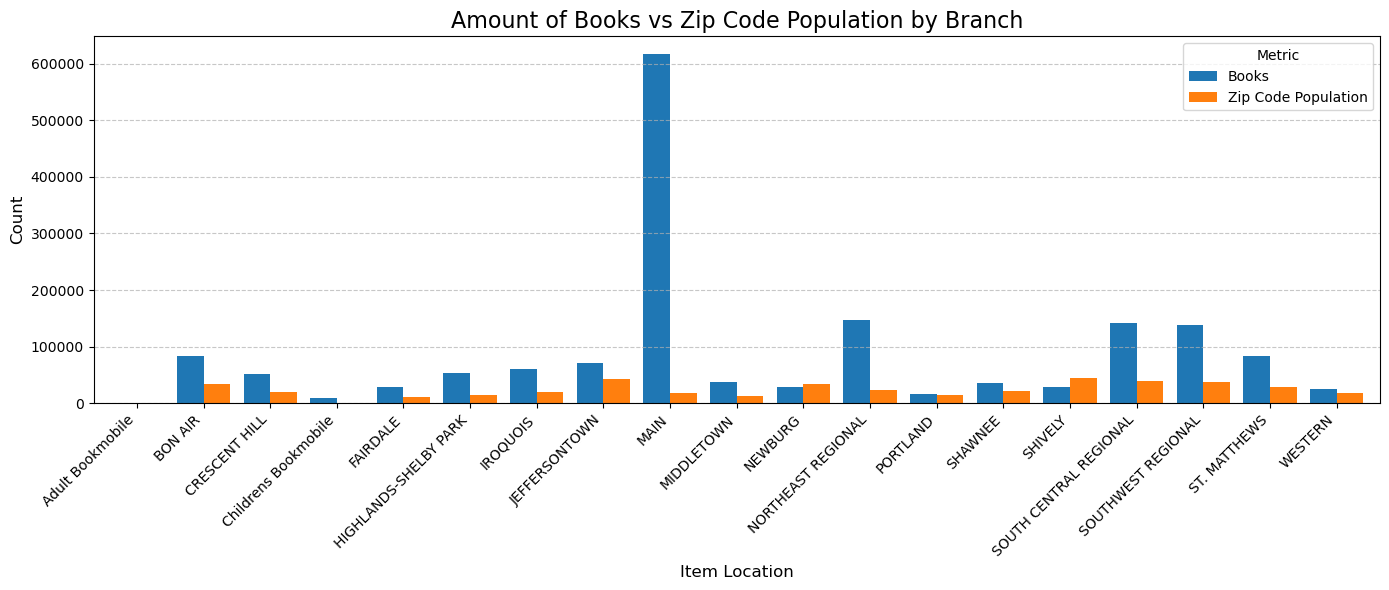

In [308]:
ax = merged.plot(
    kind="bar",
    figsize=(14, 6),
    width=0.8,
)


plt.title("Amount of Books vs Zip Code Population by Branch", fontsize=16)
plt.ylabel("Count", fontsize=12)
plt.xlabel("Item Location", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(title="Metric")
plt.tight_layout()

plt.show()

In [309]:
lfpl_df.head()

,BibNum,Title,Author,ISBN,PublicationYear,ItemType,ItemCollection,ItemLocation,ItemPrice,ReportDate,ObjectId,Name_lower
0,707409,"Jeff Immelt and the new GE way : innovation, t...","Magee, David, 1965-",9.780072e+12,2009,Book,Adult Non-Fiction,MAIN,25.95,2022/07/01 04:00:00+00,1,main
1,1341361,McGraw-Hill's American idioms dictionary,"Spears, Richard A.",9.780071e+12,2007,Book,ELL Collection,SOUTH CENTRAL REGIONAL,20.00,2022/07/01 04:00:00+00,2,south central regional
2,707411,Robin rescues dinner : 52 weeks of quick-fix m...,"Miller, Robin, 1964-",9.780307e+12,2009,Book,Adult Non-Fiction,SOUTHWEST REGIONAL,19.99,2022/07/01 04:00:00+00,3,southwest regional
3,1341362,McGraw-Hill's essential ESL grammar : a handbo...,"Lester, Mark.",9.780071e+12,2008,Book,ELL Collection,SOUTH CENTRAL REGIONAL,20.00,2022/07/01 04:00:00+00,4,south central regional
4,707411,Robin rescues dinner : 52 weeks of quick-fix m...,"Miller, Robin, 1964-",9.780307e+12,2009,Book,Adult Non-Fiction,SOUTHWEST REGIONAL,19.99,2022/07/01 04:00:00+00,5,southwest regional


## Data Wrangling and Analysis

Created a count of all items in a collection. Seeing that Adult non-fiction is by far the most heavily populated type of offering in the LFPL.

In [310]:
item_counts = lfpl_df["ItemCollection"].value_counts()

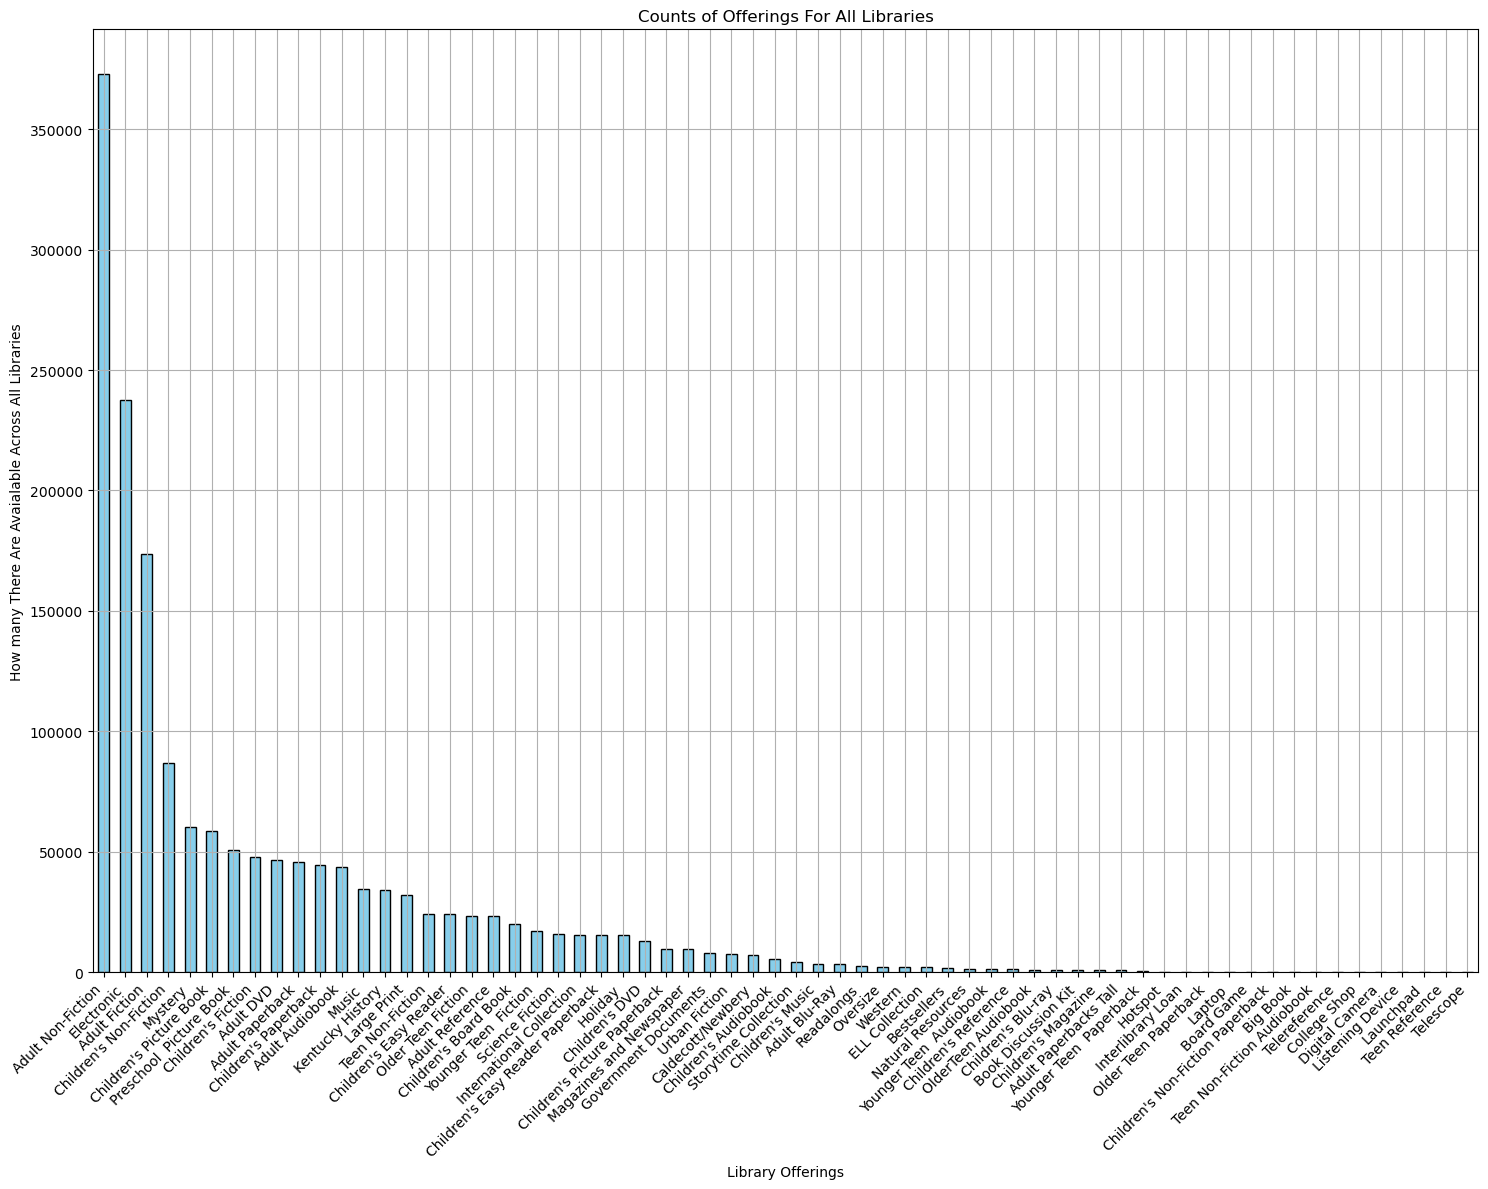

In [311]:
ax = item_counts.plot.bar(
    color="skyblue",  
    edgecolor="black", 
    rot=0,  
    figsize=(15, 12),  
    grid=True  
)
ax.set_xlabel("Library Offerings")
ax.set_ylabel("How many There Are Avaialable Across All Libraries")
ax.set_title("Counts of Offerings For All Libraries")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## Data Wrangling

Created a new DF which is just the Title and Publication year for everything in the LFPL. Also, made sure eveything in year was an integer

In [312]:
year_df = merged_df[['Title', 'PublicationYear']]
int_cols = year_df.select_dtypes(include="int64").columns

## Data Cleanup

Went into the years and identified potential issue. Biggest issues were entries where the year was zero. Below is the full list of data in the DF, note there are books from anywhere between 997 and 5150. 

In [313]:
unique_year = year_df['PublicationYear'].unique()
unique_year

array([2009, 2007, 2008, 2010, 2015, 2011, 2002, 2005, 2021, 2003, 2006,
       2022, 2019, 2016, 2014, 2017, 2004, 1991, 2012, 1989, 2013, 1990,
       2000, 2018, 2020, 2001, 1994, 1993, 1992, 1997, 1995, 1996, 1999,
       1985, 1986, 1998, 1974, 1983, 1982,    0, 1967, 1977, 1984, 1981,
       1987, 1952, 1973, 1939, 1926, 1953, 1954, 1932, 1961, 1941, 1962,
       1979, 1942, 1965, 1948, 1964, 1980, 1963, 1988, 1970, 1976, 1929,
       1975, 1978, 1968, 1943, 2050, 1971, 1930, 1935, 1895, 1949, 1947,
       1951, 1966, 1956, 1957, 1972, 1969, 1958, 1950, 1955, 1851, 1907,
       1959, 1923, 1960, 1915, 1945, 1934, 1938, 1795, 1916, 1911, 1920,
       1924, 1787, 1856, 1913, 1876, 1940, 1933, 1898, 1937, 1912, 1890,
       1878, 1880, 1928, 1892, 1909, 1919, 1917, 1914, 1946, 1944, 1900,
       1918, 1903, 1908, 1936, 1931, 1896, 1904, 1899, 1901, 1922, 1921,
       1902, 1906, 1861, 1889, 1905, 1884, 1870, 1887, 1862, 1883, 1893,
       1897, 1882, 1877, 1829, 1925, 1875, 1886, 18

## Data Cleanup

Used the code below to see what titles fell under each year. Most were only 1 or 2 titles (mostly out of the Main branch). There were a couple that were swapped to different years (Checked Google and manually adjusted publishing year.) 

In [314]:
matches_exact = year_df[year_df["PublicationYear"] ==  1554]
matches_exact

,Title,PublicationYear
133992,Qvattro orationi de M. Bartolomeo Spathaphòra...,1554


## Data Cleanup 

Any years that had information where I could not identify when it was published was removed from the dataframe using the hide filters below. 

In [315]:
year_df = year_df[(year_df[int_cols] != 1550).all(axis=1)]
year_df = year_df[(year_df[int_cols] != 2109).all(axis=1)]
year_df = year_df[(year_df[int_cols] != 2030).all(axis=1)]
year_df = year_df[(year_df[int_cols] != 2099).all(axis=1)]
year_df = year_df[(year_df[int_cols] != 5124).all(axis=1)]
year_df = year_df[(year_df[int_cols] != 120).all(axis=1)]
year_df = year_df[(year_df[int_cols] != 997).all(axis=1)]
year_df = year_df[(year_df[int_cols] != 2032).all(axis=1)]
year_df = year_df[(year_df[int_cols] != 2033).all(axis=1)]
year_df = year_df[(year_df[int_cols] != 2029).all(axis=1)]
year_df = year_df[(year_df[int_cols] != 9999).all(axis=1)]
year_df = year_df[(year_df[int_cols] != 1011).all(axis=1)]
year_df = year_df[(year_df[int_cols] != 1011).all(axis=1)]
year_df = year_df[(year_df[int_cols] != 2050).all(axis=1)]
year_df = year_df[(year_df[int_cols] != 0).all(axis=1)]

In [316]:
year_df['PublicationYear'].unique()

array([2009, 2007, 2008, 2010, 2015, 2011, 2002, 2005, 2021, 2003, 2006,
       2022, 2019, 2016, 2014, 2017, 2004, 1991, 2012, 1989, 2013, 1990,
       2000, 2018, 2020, 2001, 1994, 1993, 1992, 1997, 1995, 1996, 1999,
       1985, 1986, 1998, 1974, 1983, 1982, 1967, 1977, 1984, 1981, 1987,
       1952, 1973, 1939, 1926, 1953, 1954, 1932, 1961, 1941, 1962, 1979,
       1942, 1965, 1948, 1964, 1980, 1963, 1988, 1970, 1976, 1929, 1975,
       1978, 1968, 1943, 1971, 1930, 1935, 1895, 1949, 1947, 1951, 1966,
       1956, 1957, 1972, 1969, 1958, 1950, 1955, 1851, 1907, 1959, 1923,
       1960, 1915, 1945, 1934, 1938, 1795, 1916, 1911, 1920, 1924, 1787,
       1856, 1913, 1876, 1940, 1933, 1898, 1937, 1912, 1890, 1878, 1880,
       1928, 1892, 1909, 1919, 1917, 1914, 1946, 1944, 1900, 1918, 1903,
       1908, 1936, 1931, 1896, 1904, 1899, 1901, 1922, 1921, 1902, 1906,
       1861, 1889, 1905, 1884, 1870, 1887, 1862, 1883, 1893, 1897, 1882,
       1877, 1829, 1925, 1875, 1886, 1885, 1867, 18

In [317]:
year_df["decade"] = (year_df["PublicationYear"] // 10) * 10


In [318]:
decade_counts = (
    year_df.groupby("decade")["Title"]
      .nunique() 
      .reset_index(name="Unique Title Count")
)


## Data Analysis

Unsurprisingly there were not a lot of books before the 19th century but the titles began to rise in the 1940s and continued to grow until 2010. A sharp decline in new titles has been happening since the year 2020. Note that while the range would go until 2030 we are below the half way point to where we would need to be to keep pace with the 2010's.

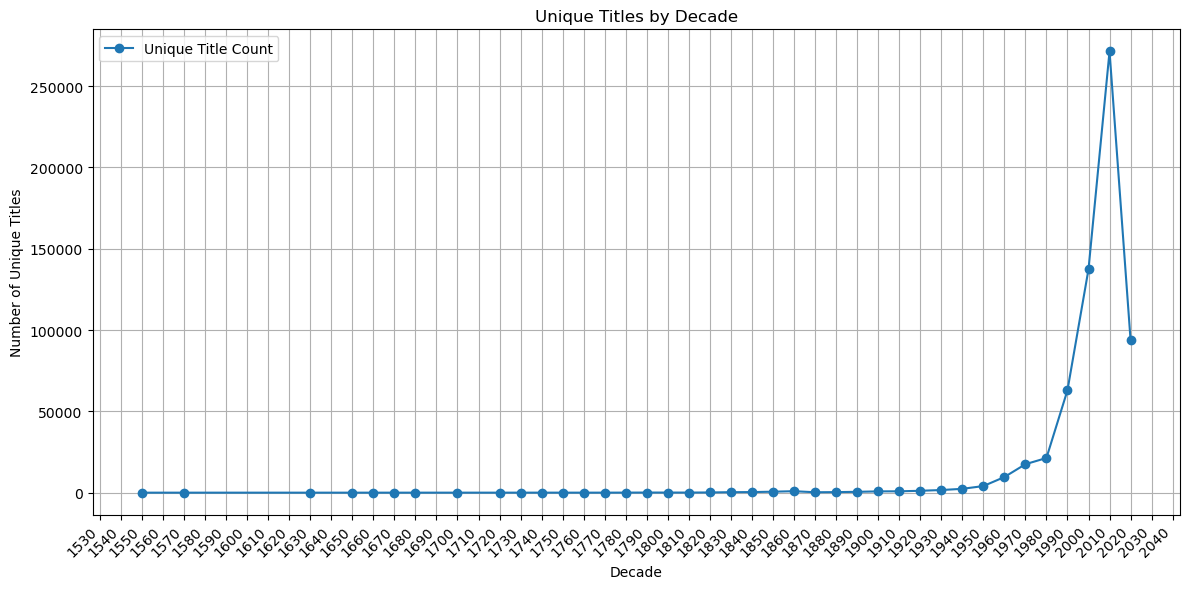

In [319]:
ax = decade_counts.plot(
    x="decade",
    y="Unique Title Count",
    kind="line",
    marker="o",
    figsize=(12, 6),
    title="Unique Titles by Decade"
)

ax.set_xlabel("Decade")
ax.set_ylabel("Number of Unique Titles")
ax.grid(True)
ax.xaxis.set_major_locator(MultipleLocator(10))

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()